# Example: calling a C array function

In [1]:
import os, ctypes
import numpy as np
import matplotlib.pyplot as plt
os.system('gcc -O2 -fPIC -shared Array_function_example.c -o Array_function_example.so')
plt.rcParams.update({
    'text.usetex': True,
    'font.family':'Times',
    'text.latex.preamble': r'\usepackage{newtxtext,newtxmath}'})
%matplotlib inline
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
def Example_1(param = 3.14):
    lib = ctypes.CDLL("Array_function_example.so")
    lib.Example_1.argtypes = [
        ctypes.POINTER(ctypes.c_double),  # double*
        ctypes.c_int,                     # int
        ctypes.c_double                   # double
    ]
    lib.Example_1.restype = None
    r = np.empty(20, dtype=np.float64)
    # Call C function
    lib.Example_1(
        r.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        len(r),
        param
    )
    print(r)
Example_1()

[3.14 3.14 3.14 3.14 3.14 3.14 3.14 3.14 3.14 3.14 3.14 3.14 3.14 3.14
 3.14 3.14 3.14 3.14 3.14 3.14]


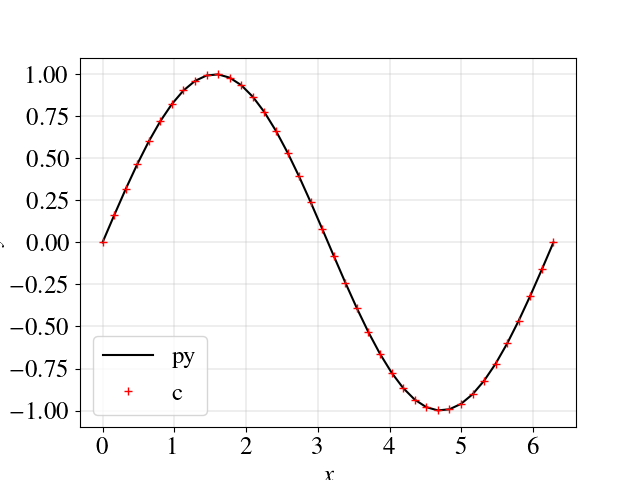

In [8]:
def Example_2(param = 2.0, x = np.linspace(0, np.pi, 40)):
    lib = ctypes.CDLL("Array_function_example.so")
    lib.Example_2.argtypes = [
        ctypes.POINTER(ctypes.c_double),  # double*
        ctypes.POINTER(ctypes.c_double),  # double*
        ctypes.c_int,                     # int
        ctypes.c_double                   # double
    ]
    lib.Example_2.restype = None
    nx = len(x)
    r = np.empty(nx, dtype=np.float64)
    # Call C function
    lib.Example_2(
        r.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        x.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        nx,
        param
    )
    return r

param = 1
x = np.linspace(0, 2*np.pi, 40)
y1 = np.sin(param * x)
y2 = Example_2(param, x)

# Make Plot
LineWidth = 2
FontSize = 18
fig, ax = plt.subplots()
ax.grid(True, which='both', linewidth = 0.3)  # `which='both'` enables major and minor grids
plt.plot(x, y1, 'k', label = 'py')
plt.plot(x, y2, '+r', label = 'c')
plt.xlabel('$x$',fontsize=FontSize,fontname='Times New Roman')
plt.ylabel('$y$',fontsize=FontSize,fontname='Times New Roman')
plt.xticks(size=FontSize)
plt.yticks(size=FontSize)
plt.legend(fontsize=FontSize,loc = 'lower left')
